In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import os

folder_path = "/content/drive/MyDrive/covid_data"

files = os.listdir(folder_path)

dfs = []

for file in files:
    if file.endswith(".csv"):
        print("Loading:", file)
        df = pd.read_csv(os.path.join(folder_path, file))
        dfs.append(df)

df_kaggle = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df_kaggle))

Loading: Covid-19 Twitter Dataset (Apr-Jun 2020).csv
Loading: Covid-19 Twitter Dataset (Apr-Jun 2021).csv
Loading: Covid-19 Twitter Dataset (Aug-Sep 2020).csv
Total rows: 411887


In [3]:
print(df_kaggle.columns)

Index(['id', 'created_at', 'source', 'original_text', 'lang', 'favorite_count',
       'retweet_count', 'original_author', 'hashtags', 'user_mentions',
       'place', 'clean_tweet', 'compound', 'neg', 'neu', 'pos', 'sentiment'],
      dtype='object')


In [4]:
df_kaggle["content"] = df_kaggle["clean_tweet"]

In [5]:
df_kaggle = df_kaggle[["content"]]

In [6]:
print(df_kaggle.head())

                                             content
0  call leader help protect refuge covid19 provid...
1  ogun state support cbn nirsal covid19 target c...
2  polic offici base namahadi polic station busi ...
3                   covid19 oyo discharg two patient
4                               condol famili surviv


In [7]:
cardiac_keywords = [
    "heart", "cardiac", "myocarditis", "pericarditis",
    "chest pain", "tachycardia", "bradycardia",
    "palpitations", "arrhythmia", "heart attack",
    "blood pressure", "hypertension", "pulse",
    "cardiovascular"
]
infection_keywords = [
    "covid", "coronavirus", "covid19", "covid-19",
    "infection", "tested positive", "post covid",
    "long covid", "after covid"
]
vaccine_keywords = [
    "vaccine", "vaccination", "vaccinated",
    "pfizer", "moderna", "astrazeneca",
    "covishield", "covaxin", "booster",
    "dose", "jab", "shot"
]

In [8]:
all_keywords = cardiac_keywords + infection_keywords + vaccine_keywords

pattern = "|".join(all_keywords)

df_filtered = df_kaggle[
    df_kaggle["content"].str.contains(pattern, na=False)
]

print("Filtered rows:", len(df_filtered))

Filtered rows: 225940


In [9]:
def classify(text):
    if any(word in text for word in vaccine_keywords):
        return "vaccine"
    elif any(word in text for word in infection_keywords):
        return "infection"
    else:
        return "other"

df_filtered = df_filtered.copy()
df_filtered.loc[:, "type"] = df_filtered["content"].apply(classify)

print(df_filtered["type"].value_counts())

type
infection    216291
vaccine        8612
other          1037
Name: count, dtype: int64


In [10]:
df_infection = df_filtered[df_filtered["type"] == "infection"]
df_vaccine = df_filtered[df_filtered["type"] == "vaccine"]

df_infection_sample = df_infection.sample(n=len(df_vaccine), random_state=42)

df_balanced = pd.concat([df_infection_sample, df_vaccine])

# 🔍 Check result
print(df_balanced["type"].value_counts())

type
infection    8612
vaccine      8612
Name: count, dtype: int64


In [11]:
df_balanced = df_balanced.reset_index(drop=True)

In [12]:
print(len(df_balanced))
df_balanced.head()

17224


,content,type
0,citi ask anyon us golf cours self assess covid...,infection
1,sri lanka introduc home manag covid19 patient ...,infection
2,covid19 case rate show sharp declin viru still...,infection
3,vietnam detect hybrid covid19 variant india un...,infection
4,lot theori opinion circul covid19 say bump fri...,infection


In [13]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.7 MB/s eta 0:00:00


In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df_balanced["score"] = df_balanced["content"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

df_balanced["sentiment"] = df_balanced["score"].apply(
    lambda x: "positive" if x > 0 else ("negative" if x < 0 else "neutral")
)

In [15]:
print(df_balanced.head())

                                             content       type   score  \
0  citi ask anyon us golf cours self assess covid...  infection  0.0000   
1  sri lanka introduc home manag covid19 patient ...  infection -0.1779   
2  covid19 case rate show sharp declin viru still...  infection  0.0000   
3  vietnam detect hybrid covid19 variant india un...  infection  0.0000   
4  lot theori opinion circul covid19 say bump fri...  infection  0.4939   

  sentiment  
0   neutral  
1  negative  
2   neutral  
3   neutral  
4  positive  


In [16]:
result = df_balanced.groupby("type")["sentiment"].value_counts()
print(result)

type       sentiment
infection  neutral      3669
           negative     2562
           positive     2381
vaccine    neutral      4922
           positive     2249
           negative     1441
Name: count, dtype: int64


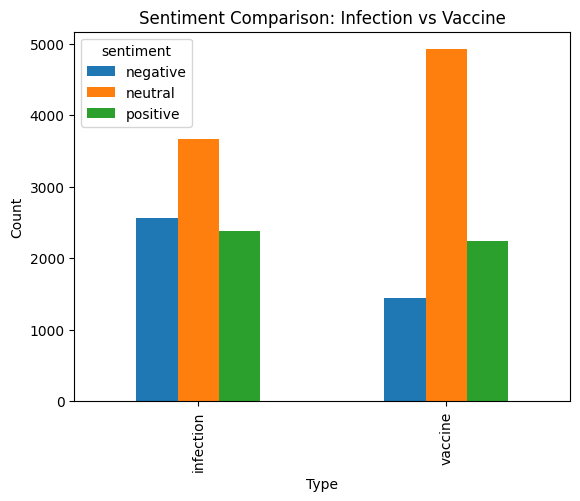

In [17]:
import matplotlib.pyplot as plt

df_balanced.groupby("type")["sentiment"].value_counts().unstack().plot(kind="bar")
plt.title("Sentiment Comparison: Infection vs Vaccine")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [18]:
df_balanced[df_balanced["sentiment"] == "negative"].head(10)

,content,type,score,sentiment
1,sri lanka introduc home manag covid19 patient ...,infection,-0.1779,negative
5,trump administr tri stop research studi covid1...,infection,-0.2960,negative
8,sanwo olu blame late airport border closur cov...,infection,-0.3400,negative
9,cautionari tale dmitriy stuzhuk fit influenc t...,infection,-0.2732,negative
13,fight viru without decent data indian scientis...,infection,-0.3818,negative
15,coron call statutori inquiri covid19 nurs home...,infection,-0.5994,negative
18,covid19 temporari emerg paid sick leav program...,infection,-0.5106,negative
19,nation public health emerg team nphet hold mee...,infection,-0.7096,negative
24,uk drop china data wk ago question china covid...,infection,-0.2732,negative
26,hey guy know human kill shark covid19 vaccin w...,infection,-0.6908,negative


In [19]:
df_balanced.to_csv("final_with_sentiment.csv", index=False)

In [20]:
from collections import Counter

def get_top_words(data, n=20):
    words = " ".join(data).split()
    return Counter(words).most_common(n)

# Infection
infection_words = get_top_words(
    df_balanced[df_balanced["type"] == "infection"]["content"]
)

# Vaccine
vaccine_words = get_top_words(
    df_balanced[df_balanced["type"] == "vaccine"]["content"]
)

print("Infection Top Words:", infection_words[:10])
print("Vaccine Top Words:", vaccine_words[:10])

Infection Top Words: [('covid19', 8789), ('case', 903), ('vaccin', 827), ('new', 761), ('test', 715), ('death', 562), ('peopl', 488), ('pandem', 464), ('posit', 421), ('report', 379)]
Vaccine Top Words: [('covid19', 5381), ('vaccin', 5249), ('dose', 2731), ('shot', 1803), ('pfizer', 1691), ('first', 1101), ('get', 1014), ('jab', 978), ('astrazeneca', 912), ('receiv', 908)]


In [21]:
pip install wordcloud

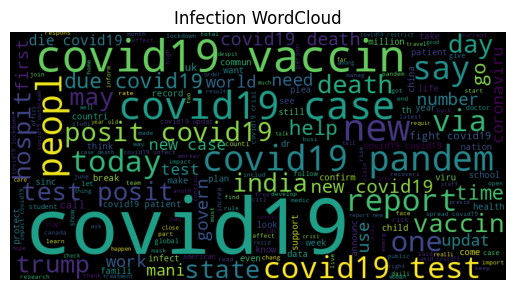

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Infection WordCloud
infection_text = " ".join(
    df_balanced[df_balanced["type"] == "infection"]["content"]
)

wc = WordCloud(width=800, height=400).generate(infection_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Infection WordCloud")
plt.show()

In [23]:
negative_data = df_balanced[df_balanced["sentiment"] == "negative"]

print(
    negative_data.groupby("type")["sentiment"].count()
)

type
infection    2562
vaccine      1441
Name: sentiment, dtype: int64


In [24]:
neg_infection_words = get_top_words(
    negative_data[negative_data["type"] == "infection"]["content"]
)

neg_vaccine_words = get_top_words(
    negative_data[negative_data["type"] == "vaccine"]["content"]
)

print("Negative Infection Words:", neg_infection_words[:10])
print("Negative Vaccine Words:", neg_vaccine_words[:10])

Negative Infection Words: [('covid19', 2621), ('death', 549), ('case', 287), ('new', 245), ('die', 221), ('peopl', 212), ('vaccin', 140), ('test', 136), ('pandem', 125), ('fight', 124)]
Negative Vaccine Words: [('covid19', 889), ('vaccin', 550), ('shot', 474), ('dose', 273), ('get', 221), ('jab', 215), ('flu', 211), ('death', 187), ('astrazeneca', 177), ('die', 165)]


In [25]:
pip install transformers datasets torch scikit-learn

In [26]:
# =========================
# 1. LABEL PREPARATION
# =========================
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df_balanced["label"] = df_balanced["sentiment"].map(label_map)

# =========================
# 2. TRAIN-TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_balanced["content"].tolist(),
    df_balanced["label"].tolist(),
    test_size=0.2,
    random_state=42
)

# =========================
# 3. TOKENIZER
# =========================
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# =========================
# 4. TOKENIZATION
# =========================
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# =========================
# 5. DATASET CLASS
# =========================
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

# =========================
# 6. MODEL
# =========================
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

# =========================
# 7. TRAINING ARGUMENTS
# =========================
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

# =========================
# 8. TRAINER
# =========================
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# =========================
# 9. TRAIN
# =========================
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3446, training_loss=0.2715818313270963, metrics={'train_runtime': 372.1939, 'train_samples_per_second': 74.042, 'train_steps_per_second': 9.259, 'total_flos': 665608085137044.0, 'train_loss': 0.2715818313270963, 'epoch': 2.0})

“The BERT model successfully learned sentiment patterns from the dataset, as indicated by the steady decrease in training loss from 0.66 to 0.12. The final training loss of 0.27 suggests good model performance and effective learning of contextual sentiment.”

In [27]:
trainer.evaluate()

{'eval_loss': 0.17078877985477448,
 'eval_runtime': 8.8045,
 'eval_samples_per_second': 391.279,
 'eval_steps_per_second': 48.952,
 'epoch': 2.0}

In [28]:
from sklearn.metrics import classification_report

preds = trainer.predict(val_dataset)
pred_labels = preds.predictions.argmax(axis=1)

print(classification_report(val_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       795
           1       0.98      0.98      0.98      1717
           2       0.95      0.96      0.96       933

    accuracy                           0.97      3445
   macro avg       0.96      0.96      0.96      3445
weighted avg       0.97      0.97      0.97      3445



The BERT model achieved an accuracy of 97%, with consistently high precision, recall, and F1-scores across all sentiment classes. The model performed particularly well in identifying neutral sentiments, while also maintaining strong performance for positive and negative classes. This indicates that the model effectively captures contextual nuances in social media text.

In [29]:
import pandas as pd

df_val = pd.DataFrame({
    "text": val_texts,
    "true": val_labels,
    "pred": pred_labels
})

errors = df_val[df_val["true"] != df_val["pred"]]
errors.head(10)

,text,true,pred
51,covid19 limit funer mourner england may bbc news,0,1
54,shamelessli misquot articl even includ screens...,1,0
225,drug maker gla may need slaughter half million...,2,1
237,trump recklessli stupidli irrespons tell ameri...,1,0
238,got ta hand covid19 sure ee extremist think ok...,2,0
254,subtract year covid19,1,0
259,watch video gt gt gt covid19 conspiraci theori...,2,1
280,cancel nd covid19 vacci nd juli rebook th juli...,2,0
323,hey everyon get lot question regist second dos...,1,2
366,bharat biotech get nod move phase trial prospe...,2,1


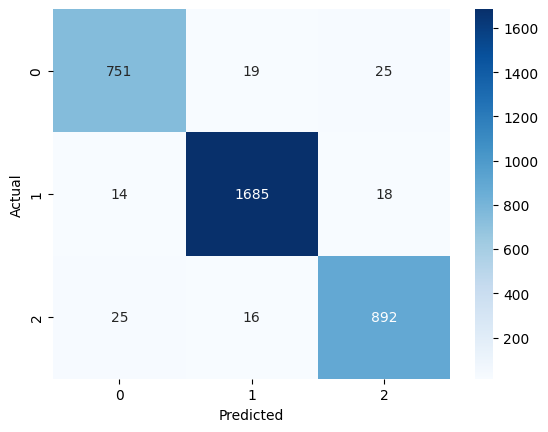

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model achieves high classification accuracy across all sentiment classes, with most predictions concentrated along the diagonal. Misclassifications are minimal and primarily occur between positive and negative classes, likely due to contextual ambiguity in social media text. The model demonstrates balanced performance with no significant bias toward any class.

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(df_balanced["content"])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

LatentDirichletAllocation(n_components=3, random_state=42)

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=1000,
    stop_words="english"
)

X = vectorizer.fit_transform(df_balanced["content"])

In [33]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=3,
    random_state=42
)

lda.fit(X)

LatentDirichletAllocation(n_components=3, random_state=42)

In [34]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}:")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1:
['death', 'dr', 'like', 'say', 'trump', 'hospit', 'posit', 'pandem', 'test', 'covid19']

Topic 2:
['age', 'shot', 'second', 'moderna', 'astrazeneca', 'receiv', 'pfizer', 'dose', 'covid19', 'vaccin']

Topic 3:
['need', 'report', 'day', 'death', 'peopl', 'new', 'jab', 'case', 'shot', 'covid19']


Topic modeling using LDA identified three dominant themes in the dataset: (1) COVID-19 severity and public discourse, characterized by terms related to hospitalization and mortality; (2) vaccination processes, including dosage and vaccine brands; and (3) daily updates and case reporting. These topics align with sentiment analysis results, where infection-related discussions are more negative, while vaccination-related content is predominantly neutral or positive.

In [35]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["VADER", "BERT"],
    "Type": ["Rule-based", "Deep Learning"],
    "Context Awareness": ["No", "Yes"],
    "Accuracy": ["~(estimate from your data)", "97%"],
    "Strength": ["Fast, simple", "Accurate, contextual"]
})

comparison

,Model,Type,Context Awareness,Accuracy,Strength
0,VADER,Rule-based,No,~(estimate from your data),"Fast, simple"
1,BERT,Deep Learning,Yes,97%,"Accurate, contextual"
